In [22]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import gzip
import os
from functions import *
import matplotlib.pyplot as plt
from matplotlib import rc
import pyart
from matplotlib.ticker import MultipleLocator
import zstandard as zstd
import io

In [23]:
# lidar file to read in
des_file = "20241103044618_CAPPI_1242.nc.zst"
# date/time info of lidar scans
des_year = des_file[:4]
des_mon = des_file[4:6]
des_day = des_file[6:8]
des_hour = des_file[8:10]
des_min = des_file[10:12]
des_sec = des_file[12:14]
# lidar system info
des_sys = "ARRC" # ARRC, WG100-L0AD00003JP, or WG100-L0AD00004JP
lidar_loc = "ARRC Mobile" # Hampton, VA or ARRC
# directory = f"/data/arrcwx/robbyfrost/lidar_obs/{des_sys}/{des_year}/{des_mon}/{des_day}/"
directory = f"/data/arrcwx/MetroWeather/{des_sys}/{des_year}/{des_mon}/{des_year}{des_mon}{des_day}/" 
# directory for saving figues
figdir = f"/home/robbyfrost/Analysis/TurbTor_Lidar/figures/{des_sys}/{des_year}/{des_mon}/{des_day}/"
os.makedirs(figdir, exist_ok=True)

# scan strategy info
des_elev = 5.
# snr threshold for masking out data
snr_cut = -10
# start and end azimuths for averaging
az_start, az_end = 293.925, 358.99

# full path to lidar file
file_path = directory + des_file
# read in compressed lidar file
with open(file_path, 'rb') as compressed_file:
    decompressor = zstd.ZstdDecompressor()
    # Decompress into memory
    decompressed_data = decompressor.decompress(compressed_file.read())
    # Create a file-like object from bytes
    file_like_obj = io.BytesIO(decompressed_data)
    # create xarray dataset
    ds = xr.open_dataset(file_like_obj, engine='h5netcdf')

# only include desired elevation
ds = ds.where(ds.elevation == des_elev, drop=True)
# filter out low snr on desired variables
good_snr = 10 * np.log10(ds.snr-1)
ds['dpl'] = ds.dpl.where(good_snr > snr_cut)
# ds['snr'] = ds.snr.where(good_snr > snr_cut)

In [24]:
# account for range offset
range_offset = 1425 # meters
start_point = np.argmin(abs(ds.ranges[:,0].data-range_offset))+1
# scan dimensions
az = ds.azimuth.data# * -1 + 90
r = ds.ranges[start_point:,0].data - range_offset
el = ds.elevation.data
# radial velocity
vr = ds.dpl[:,0,start_point:].data * -1
vr_smoothed = xr.DataArray(vr, dims=("az","r"), coords={'az': az, 'r': r}).rolling(az=3,r=3).mean().values
# calculate vertical vorticity
vort_z = ( (vr[1:,:] - vr[:-1,:]) / (np.deg2rad(az[1:]) - np.deg2rad(az[:-1]))[:,np.newaxis] ) * (1 / r)
vort_z_smoothed = ( (vr_smoothed[1:,:] - vr_smoothed[:-1,:]) / (np.deg2rad(az[1:]) - np.deg2rad(az[:-1]))[:,np.newaxis] ) * (1 / r)
# other observations
pwr = ds.pwr[:,0,start_point:].data * 100
snr = 10 * np.log10(ds.snr[:,0,start_point:].data - 1)
sw = ds.wth[:,0,start_point:].data
noise_level = ds.noise_level[:,0,start_point:].data
# power_spectra = ds.power_spectra[:,0,start_point:].data
doppler_velocity = ds.doppler_velocity.data
# lidar information
ob_method = ds.attrs['observation_method']
serial_number = ds.attrs['serial_number']
lat = ds.latitude.data
lon = ds.longitude.data
altitude = ds.altitude.data
# scan setting information
rpm_azimuth = ds.rpm_azimuth[start_point:].data
# scan time information
record_start_time = ds.start_time.data
start_time = ds.attrs['start_time'][11:19]
start_date = ds.attrs['start_time'][:10]
end_time = ds.attrs['end_time'][11:19]
end_date = ds.attrs['end_time'][:10]

In [25]:
radar = pyart.testing.make_empty_ppi_radar(r.size, az.size, 1)

In [26]:
# Create metadata for the field
vr_field = {
    'data': vr,
    'long_name': 'Doppler velocity',
    'units': 'm/s',
    'standard_name': 'radial_velocity',
    'comments': 'Filtered Doppler velocity using SNR thresholding.'
}
# Add the field to the radar object
radar.add_field('vr', vr_field)

In [27]:
radar.fields.keys()

dict_keys(['vr'])

In [29]:
#Barnes Analysis
grid_barnes = pyart.map.grid_from_radars(
    radar,
    grid_shape=(41, 401, 401),
    gridding_algo = 'map_gates_to_grid',
    weighting_function = 'barnes',
    # gatefilters = gfilter,
    grid_limits=(
        (
            0.0,
            20000,
        ),
        (-100000.0, 100000.0),
        (-100000, 100000.0),
    ),
)

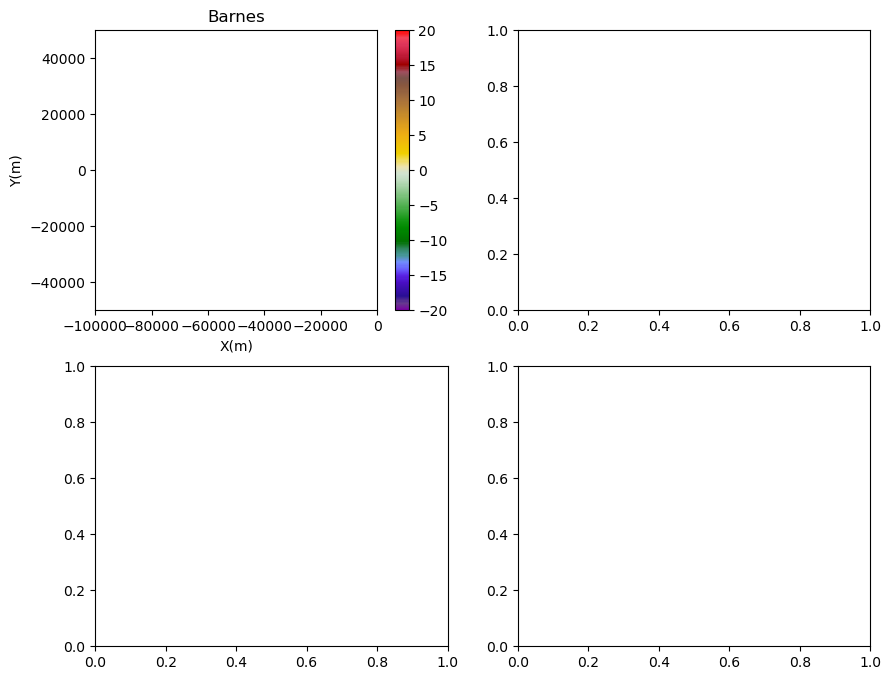

In [30]:
[X,Y]=np.meshgrid(grid_barnes.x["data"],grid_barnes.y["data"])
Zb=grid_barnes.fields['vr']['data']

fig,ax=plt.subplots(2,2,figsize=(10,8))
lev=5 #Level of analysis
pcm=ax[0,0].pcolormesh(X,Y,np.squeeze(Zb[lev,:,:]),cmap='pyart_Carbone42',vmin=-20,vmax=20)
ax[0,0].set_xlabel('X(m)')
ax[0,0].set_ylabel('Y(m)')
ax[0,0].set_title('Barnes')
ax[0,0].set_xlim(-100000,0)
ax[0,0].set_ylim(-50000,50000)
plt.colorbar(pcm,ax=ax[0,0])